# Week 10 - Restful Web Services
#### Part 4
### Notebook created by Jonathan Penava
By the end of this lesson you should know the steps to add Restful Web Services to a ML application.

## Overview
- Flask and Postman Setup
- Get and Post
- Consuming Web Services
- <span style="color:red;">Web Service with ML</span>

We are going to start with the Titanic dataset from week 4, and we are going to set it up to work as a web service.  Staring with setting up and cleaning, and training our data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')

titanic.drop('embark_town', axis=1, inplace=True)
titanic.drop('embarked', axis=1, inplace=True)
titanic.drop('deck', axis=1, inplace=True)
titanic.drop('class', axis=1, inplace=True)
titanic.drop('alive', axis=1, inplace=True)
titanic.drop('fare', axis=1, inplace=True)

titanic.replace('male', 0, inplace=True)
titanic.replace('female', 1, inplace=True)
titanic.replace('man', 0, inplace=True)
titanic.replace('woman', 1, inplace=True)
titanic.replace('child', 2, inplace=True)

titanic.dropna(axis=0, inplace=True)

titanic.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_24980\3113819734.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic.replace('female', 1, inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_24980\3113819734.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic.replace('child', 2, inplace=True)


,survived,pclass,sex,age,sibsp,parch,who,adult_male,alone
0,0,3,0,22.0,1,0,0,True,False
1,1,1,1,38.0,1,0,1,False,False
2,1,3,1,26.0,0,0,1,False,True
3,1,1,1,35.0,1,0,1,False,False
4,0,3,0,35.0,0,0,0,True,True


In [2]:
#Remove the dependent data (our y) from our independent data (our x values)
X, y = titanic.drop('survived', axis=1), titanic['survived'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

Starting our web service

In [3]:
from flask import Flask, request
app = Flask(__name__)

We want create a sample url that will allow users who use our web service know how to send information.  We are going to start with the first record of our dataframe without the survived column.

In [4]:
titanic.drop('survived', axis=1).iloc[0]

pclass            3
sex               0
age            22.0
sibsp             1
parch             0
who               0
adult_male     True
alone         False
Name: 0, dtype: object

We need this to look like a JSON string.  To do that we are going to format our pandas series into a JSON string.https://pandas.pydata.org/docs/reference/api/pandas.Series.to_json.html

In [5]:
titanic.drop('survived', axis=1).iloc[0].to_json(orient="index")

'{"pclass":3,"sex":0,"age":22.0,"sibsp":1,"parch":0,"who":0,"adult_male":true,"alone":false}'

The above record will be our sample.  Now we create our web service method.

In [6]:
@app.get("/titanic/sample")
def get_example():
    return titanic.drop('survived', axis=1).iloc[0].to_json(orient="index")

Now we want to be able to process a request.  We need to read our JSON record, convert it to a dataframe and test it with our model.  We are going to return the result, but we need to return our result as a String.

In [7]:
@app.post("/titanic/survive")
def test_sample():
    if request.is_json:
        person = request.get_json() #Get the JSON from postman.
        df = pd.DataFrame([person]) #Convert JSON to dataframe.
        result = logmodel.predict(df) #Test our result
        return '{}'.format(result[0]) #Return the result
    return {"error": "Request must be JSON"}

Testing out our application

In [8]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


127.0.0.1 - - [02/Dec/2025 15:48:29] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [02/Dec/2025 15:48:31] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [02/Dec/2025 15:48:32] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [02/Dec/2025 15:48:32] "GET / HTTP/1.1" 404 -


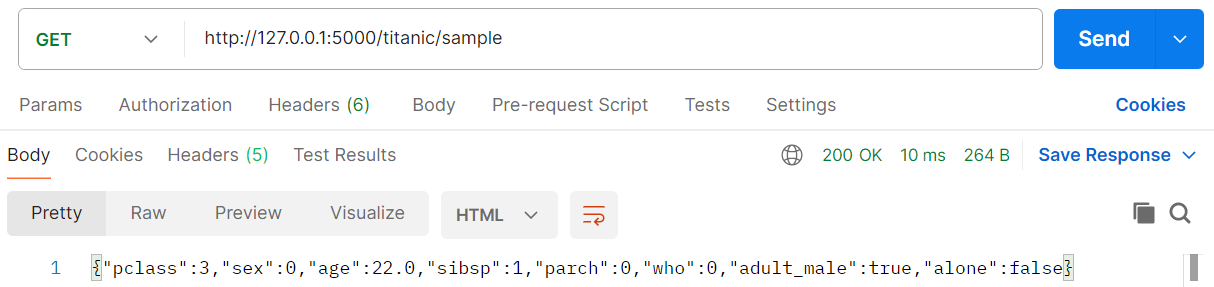

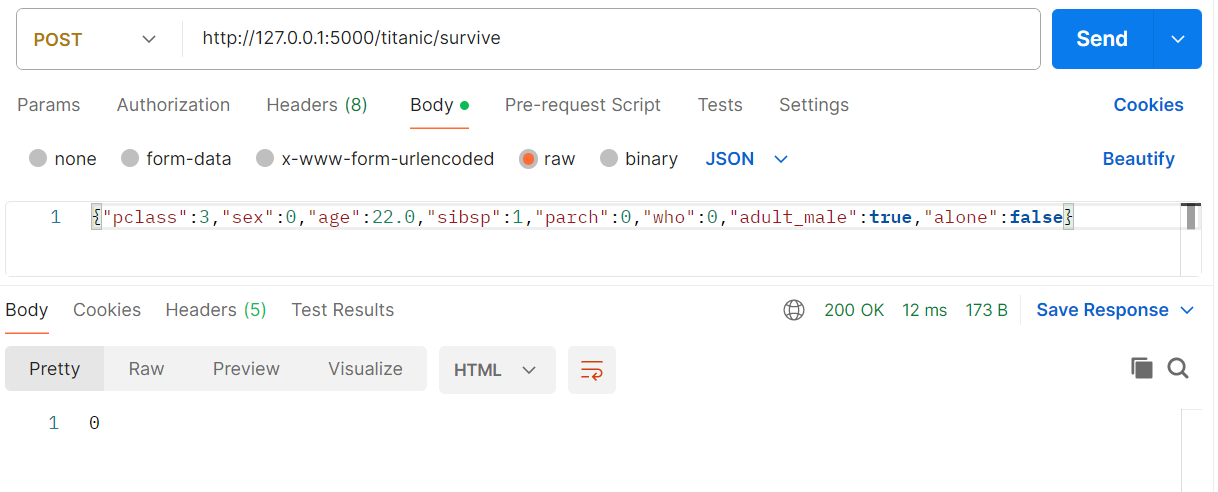